<a href="https://colab.research.google.com/github/UtsaviKalani/Car_Price_Prediction/blob/main/Dog_expression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import files
uploaded = files.upload()   # Upload your ZIP file

Saving archive (1).zip to archive (1).zip


In [7]:
import zipfile
import os

zip_path = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

print("Files extracted!")

Files extracted!


In [8]:
base_path = "/content/Dog Emotion"

for root, dirs, files in os.walk(base_path):
    print(root, len(files))

/content/Dog Emotion 1
/content/Dog Emotion/relaxed 1000
/content/Dog Emotion/happy 1000
/content/Dog Emotion/angry 1000
/content/Dog Emotion/sad 1000


In [9]:
import pandas as pd

csv_path = os.path.join(base_path, "labels.csv")
df = pd.read_csv(csv_path)

print(df.head())
print(df.columns)

   Unnamed: 0                               filename    label
0           0  yubL63eiiPmoRru8Z2K2yRo0NnGDCL683.jpg      sad
1           1  c1tVljKiLM9q2zTBuQGWpxmzBuSeBR437.jpg      sad
2           2  RbzNOvY5GIAl3PSjIRTKpEkQs1NByq575.jpg    angry
3           3  gKujaBuWYezz0yWK9ydTFVi6LbQtXe397.jpg    angry
4           4  U0hJ2ryOu1IOuYpc01O7RngPYa8Xvz795.jpg  relaxed
Index(['Unnamed: 0', 'filename', 'label'], dtype='object')


In [10]:
# Remove useless column
df = df.drop(columns=['Unnamed: 0'])

# Create correct image path
df['image_path'] = df['label'].apply(lambda x: base_path + "/" + x) + "/" + df['filename']

# Keep only needed columns
df = df[['filename', 'label', 'image_path']]

print(df.head())

                                filename    label  \
0  yubL63eiiPmoRru8Z2K2yRo0NnGDCL683.jpg      sad   
1  c1tVljKiLM9q2zTBuQGWpxmzBuSeBR437.jpg      sad   
2  RbzNOvY5GIAl3PSjIRTKpEkQs1NByq575.jpg    angry   
3  gKujaBuWYezz0yWK9ydTFVi6LbQtXe397.jpg    angry   
4  U0hJ2ryOu1IOuYpc01O7RngPYa8Xvz795.jpg  relaxed   

                                          image_path  
0  /content/Dog Emotion/sad/yubL63eiiPmoRru8Z2K2y...  
1  /content/Dog Emotion/sad/c1tVljKiLM9q2zTBuQGWp...  
2  /content/Dog Emotion/angry/RbzNOvY5GIAl3PSjIRT...  
3  /content/Dog Emotion/angry/gKujaBuWYezz0yWK9yd...  
4  /content/Dog Emotion/relaxed/U0hJ2ryOu1IOuYpc0...  


In [11]:
import os

print(df['image_path'].iloc[0])
print("Exists:", os.path.exists(df['image_path'].iloc[0]))

/content/Dog Emotion/sad/yubL63eiiPmoRru8Z2K2yRo0NnGDCL683.jpg
Exists: True


In [12]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

print("Train:", len(train_df))
print("Test:", len(test_df))

Train: 3200
Test: 800


In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='label',
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=32
)

test_gen = test_datagen.flow_from_dataframe(
    test_df,
    x_col='image_path',
    y_col='label',
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=32
)

Found 3200 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.


In [14]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,588 (9.26 MB)

 Trainable params: 167,044 (652.52 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - accuracy: 0.4778 - loss: 1.5130 - val_accuracy: 0.6025 - val_loss: 1.0039
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 222s 2s/step - accuracy: 0.6075 - loss: 1.0262 - val_accuracy: 0.6150 - val_loss: 0.9015
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 220s 2s/step - accuracy: 0.6491 - loss: 0.8934 - val_accuracy: 0.6463 - val_loss: 0.8480
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 232s 2s/step - accuracy: 0.6812 - loss: 0.7875 - val_accuracy: 0.6550 - val_loss: 0.8531
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 221s 2s/step - accuracy: 0.7025 - loss: 0.7244 - val_accuracy: 0.6687 - val_loss: 0.8111
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 222s 2s/step - accuracy: 0.7256 - loss: 0.6672 - val_accuracy: 0.6538 - val_loss: 0.8506
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step - accuracy: 0.7491 - loss: 0.6523 - val_accuracy: 0.6888 - val_loss: 0.8178
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 224s 2s/step - accuracy: 0.7503 - loss: 0.6336 - val_accu

In [16]:
loss, acc = model.evaluate(test_gen)
print("Test Accuracy:", acc)

25/25 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.6850 - loss: 0.8090
Test Accuracy: 0.6850000023841858


In [17]:
base_model.trainable = True

# Freeze first few layers (keep pretrained knowledge)
for layer in base_model.layers[:100]:
    layer.trainable = False

import tensorflow as tf

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # very low LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=10
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 353s 3s/step - accuracy: 0.6728 - loss: 0.8126 - val_accuracy: 0.6888 - val_loss: 0.7863
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 330s 3s/step - accuracy: 0.7156 - loss: 0.7064 - val_accuracy: 0.6875 - val_loss: 0.7872
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 332s 3s/step - accuracy: 0.7191 - loss: 0.6940 - val_accuracy: 0.7025 - val_loss: 0.7613
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 322s 3s/step - accuracy: 0.7584 - loss: 0.6109 - val_accuracy: 0.7050 - val_loss: 0.7501
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 331s 3s/step - accuracy: 0.7584 - loss: 0.6067 - val_accuracy: 0.7188 - val_loss: 0.7523
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 315s 3s/step - accuracy: 0.7844 - loss: 0.5578 - val_accuracy: 0.7350 - val_loss: 0.7301
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 324s 3s/step - accuracy: 0.7747 - loss: 0.5617 - val_accuracy: 0.7475 - val_loss: 0.7042
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 329s 3s/step - accuracy: 0.8041 - loss: 0.5161 - val_accu

In [18]:
loss, acc = model.evaluate(test_gen)
print("Test Accuracy:", acc)

25/25 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.7588 - loss: 0.6655
Test Accuracy: 0.7587500214576721


In [19]:
model.save("dog_emotion_model_before_finetune.keras")

In [20]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.3,
    horizontal_flip=True,
    shear_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1
)

In [21]:
print(df['label'].value_counts())

label
sad        1000
angry      1000
relaxed    1000
happy      1000
Name: count, dtype: int64


In [22]:
loss, acc = model.evaluate(test_gen)
print("Test Accuracy:", acc)

25/25 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.7588 - loss: 0.6655
Test Accuracy: 0.7587500214576721


In [23]:
base_model.trainable = True

# Freeze most layers, train only top layers
for layer in base_model.layers[:-50]:
    layer.trainable = False

import tensorflow as tf

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-6),  # VERY LOW LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=5
)

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 336s 3s/step - accuracy: 0.8263 - loss: 0.4498 - val_accuracy: 0.7600 - val_loss: 0.6629
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 318s 3s/step - accuracy: 0.8175 - loss: 0.4563 - val_accuracy: 0.7600 - val_loss: 0.6599
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 312s 3s/step - accuracy: 0.8313 - loss: 0.4520 - val_accuracy: 0.7575 - val_loss: 0.6570
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 317s 3s/step - accuracy: 0.8309 - loss: 0.4486 - val_accuracy: 0.7625 - val_loss: 0.6546
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 318s 3s/step - accuracy: 0.8259 - loss: 0.4418 - val_accuracy: 0.7588 - val_loss: 0.6542


In [24]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=10,
    callbacks=[reduce_lr]
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 320s 3s/step - accuracy: 0.8375 - loss: 0.4252 - val_accuracy: 0.7588 - val_loss: 0.6535 - learning_rate: 1.0000e-06
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 310s 3s/step - accuracy: 0.8388 - loss: 0.4244 - val_accuracy: 0.7600 - val_loss: 0.6527 - learning_rate: 1.0000e-06
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 319s 3s/step - accuracy: 0.8400 - loss: 0.4276 - val_accuracy: 0.7575 - val_loss: 0.6527 - learning_rate: 1.0000e-06
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 311s 3s/step - accuracy: 0.8441 - loss: 0.4233 - val_accuracy: 0.7575 - val_loss: 0.6551 - learning_rate: 1.0000e-06
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 318s 3s/step - accuracy: 0.8353 - loss: 0.4249 - val_accuracy: 0.7588 - val_loss: 0.6543 - learning_rate: 1.0000e-06
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 309s 3s/step - accuracy: 0.8256 - loss: 0.4495 - val_accuracy: 0.7575 - val_loss: 0.6556 - learning_rate: 1.0000e-06
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 310s 3s/step - acc

In [25]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [26]:
target_size=(256, 256)

In [27]:
model.save("dog_emotion_model_final.keras")

In [36]:
from google.colab import files
uploaded = files.upload()

Saving 2312313.jpg to 2312313.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


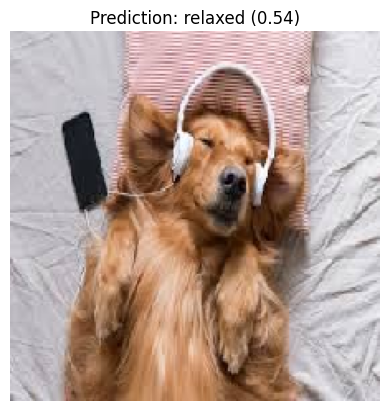

Prediction: relaxed
Confidence: 0.5435541


In [37]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Get uploaded image name
img_path = list(uploaded.keys())[0]

# Load and preprocess image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)
class_names = ['angry', 'happy', 'relaxed', 'sad']

predicted_class = class_names[np.argmax(pred)]
confidence = np.max(pred)

# Show image
plt.imshow(img)
plt.title(f"Prediction: {predicted_class} ({confidence:.2f})")
plt.axis('off')
plt.show()

print("Prediction:", predicted_class)
print("Confidence:", confidence)

In [30]:
from google.colab import files
files.download("dog_emotion_model_final.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
loss, acc = model.evaluate(test_gen)
print("Test Accuracy:", acc)

25/25 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.7563 - loss: 0.6529
Test Accuracy: 0.7562500238418579
